## OBIMD TO SA-1B FORMAT

In [4]:
import json
import cv2
from matplotlib import pyplot as plt
import numpy as np
import os
from PIL import Image
from pycocotools import mask as maskUtils
from tqdm import tqdm


with open('data/label.json') as f:
    datas = json.load(f)
image_root = 'data/OBIMD_rubbing'
output_dir = 'data/OBIMD_facsimile_json'
char_id = 0
for image_id, data in tqdm(enumerate(datas)):
    image_name = os.path.basename(data['Rubbing'])
    facsimile = cv2.imread(os.path.join('data/OBIMD_facsimile_no_boarder', image_name), flags=cv2.IMREAD_GRAYSCALE)
    # CHECK SHAPE etc.
    W, H = Image.open(os.path.join(image_root, image_name)).size
    image_info = dict(image_id=image_id, width=W, height=H, file_name=image_name)
    annotations = []
    oracle_chars = []
    for sentence in data['RecordUtilSentenceGroupVoList']:
        for char in sentence["RecordUtilOracleCharVoList"]:
            x, y, w, h = list(map(int, char['Position'].split(',')))
            try:
                if np.any(facsimile[y:min(y+h, H), x:min(x+w, W)] > 0):
                    oracle_chars.append(char) # get available chars
            except:
                pass
    for char in oracle_chars:
        mask = np.zeros_like(facsimile)
        x, y, w, h = list(map(int, char['Position'].split(',')))
        mask[y:min(y+h, H), x:min(x+w, W)] = facsimile[y:min(y+h, H), x:min(x+w, W)] # TOFIX: check area?
        for _char in oracle_chars:
            if char == _char:
                continue
            _x, _y, _w, _h = list(map(int, _char['Position'].split(',')))
            mask[_y:min(_y+_h, H), _x:min(_x+_w, W)] = 0 # remove other chars
        mask = np.asfortranarray(mask)
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        area = maskUtils.area(rle)
        bbox = maskUtils.toBbox(rle)
        annotations.append(dict(id=char_id, bbox=bbox.astype(int).tolist(), area=int(area), segmentation=rle))
        char_id += 1
    with open(os.path.join(output_dir, f'{image_name.split(".")[0]}.json'), 'w') as f:
        json.dump(dict(image_info=image_info, annotations=annotations), f, indent=2)

10077it [02:52, 58.45it/s]


In [ ]:
# 复制一下输出的label看看效果是不是对的？
# check一下area的最小值
# check到底有没有drop的

## SAM EVAL

### GRID MODE: GRID由于文字太稀疏导致不生效

### BOX MODE

In [19]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import numpy as np
import json
import os
from matplotlib import pyplot as plt
from pycocotools import mask as maskUtils

sam2_checkpoint = "sam2_logs/configs/sam2.1_training/sam2.1_hiera_l_OBIMD.yaml/checkpoints/checkpoint.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device='cuda')

predictor = SAM2ImagePredictor(sam2_model)

In [20]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))  
    
def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [26]:
miou = []
for img_path in sorted(os.listdir('data/OBIMD_test100/JPEGImages')):
    image = cv2.imread(os.path.join('data/OBIMD_test100/JPEGImages', img_path))
    base_name = os.path.splitext(img_path)[0]
    with open(os.path.join('data/OBIMD_test100/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)
    predictor.set_image(image)
    input_box = []
    gt_masks = []
    for d in data['annotations']:
        input_box.append(d['bbox'])
        binary_mask = maskUtils.decode(d['segmentation'])
        gt_masks.append(binary_mask)
    input_box = np.array(input_box).reshape(-1, 4)
    input_box[:, 2:] += input_box[:, :2]  # Convert from [x, y, w, h] to [x0, y0, x1, y1]
    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box[None, :],
        multimask_output=False,
    )
    for box, mask, gt_mask in zip(input_box, masks, gt_masks):
        x0, y0, x1, y1 = box
        pred = mask[0, y0:y1, x0:x1]
        gt = gt_mask[y0:y1, x0:x1]
        if np.sum(gt) == 0:
            continue
        miou.append(np.sum(pred * gt) / (np.sum(pred) + np.sum(gt) - np.sum(pred * gt)))    
print(np.mean(miou))

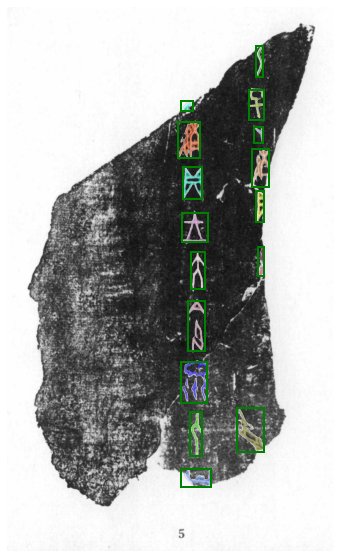

In [21]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.squeeze(0), plt.gca(), random_color=True)
for box in input_box:
    show_box(box, plt.gca())
plt.axis('off')
plt.show()